In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def f(x):
    eqs = [(-2/x), 2/(x**2),np.sin(np.log(x))/(x**2)]
    return eqs

def real_f(x):
    return 1.1392070132*x + (-0.0392070132)/(x**2) - (3/10)*np.sin(np.log(x)) - (1/10)*np.cos(np.log(x))


In [3]:
def abs_error(t_disc,y_real,y_pred):

    error = abs(y_real(t_disc) - y_pred[2][0])


    erro = np.column_stack(([y_pred[0],y_pred[1],y_pred[2][0],real_f(t_disc), error]))

    erro_df = pd.DataFrame(erro, columns = ["u1(x)","v1(x)", "w(x)","y(x)", "|y(x) - w(x)|"],
                        index = np.round(t,2))

    return erro_df

In [4]:
def shooting(ti,tf,h,f,alpha,beta):
    N = int(np.ceil((tf - ti)/h))
    t = np.zeros(N + 1)
    u = np.zeros(shape = (2,N + 1))
    v = np.zeros(shape = (2,N + 1))
    t[0] = ti
    u[0, 0] = alpha
    u[1, 0] = 0
    v[0, 0] = 0
    v[1, 0] = 1

    k1 = np.zeros(2)
    k2 = np.zeros(2)
    k3 = np.zeros(2)
    k4 = np.zeros(2)

    k_1 = np.zeros(2)
    k_2 = np.zeros(2)
    k_3 = np.zeros(2)
    k_4 = np.zeros(2)

    for i in range(N):
        k1[0] = h*u[1, i]
        k1[1] = h*(f(t[i])[0]*u[1, i] + f(t[i])[1]*u[0, i] + f(t[i])[2])
        k2[0] = h*(u[1, i] + (1/2)*k1[1])
        k2[1] = h*((f(t[i] + h/2))[0]*(u[1, i] + (1/2)*k1[1]) + f(t[i] + h/2)[1]*(u[0, i] + (1/2)*k1[0]) + f(t[i] + h/2)[2])

        k3[0] = h*(u[1 , i] + (1/2)*k2[1])
        k3[1] = h*(f(t[i] + h/2)[0]*(u[1, i] + (1/2)*k2[1]) + f(t[i] + h/2)[1]*(u[0, i] + (1/2)*k2[0]) + f(t[i] + h/2)[2])
        k4[0] = h*(u[1, i] + k3[1])
        k4[1] = h*(f(t[i] + h)[0]*(u[1, i] + k3[1]) + f(t[i] + h)[1]*(u[0, i] + k3[0]) + f(t[i] + h)[2])

        u[0, i + 1] = u[0, i] + (1/6)*(k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
        u[1, i + 1] = u[1, i] + (1/6)*(k1[1] + 2*k2[1] + 2*k3[1] + k4[1])

        k_1[0] = h*v[1, i]
        k_1[1] = h*(f(t[i])[0]*v[1, i] + f(t[i])[1]*v[0, i])
        k_2[0] = h*(v[1, i] + (1/2)*k_1[1])
        k_2[1] = h*(f(t[i] + h/2)[0]*(v[1, i] + (1/2)*k_1[1]) + f(t[i] + h/2)[1]*(v[0, i] + (1/2)*k_1[0]))

        k_3[0] = h*(v[1 , i] + (1/2)*k_2[1])
        k_3[1] = h*(f(t[i] + h/2)[0]*(v[1, i] + (1/2)*k_2[1]) + f(t[i] + h/2)[1]*(v[0, i] + (1/2)*k_2[0]))
        k_4[0] = h*(v[1, i] + k_3[1])
        k_4[1] = h*(f(t[i] + h)[0]*(v[1, i] + k_3[1]) + f(t[i] + h)[1]*(v[0, i] + k_3[0]))

        v[0, i + 1] = v[0, i] + (1/6)*(k_1[0] + 2*k_2[0] + 2*k_3[0] + k_4[0])
        v[1, i + 1] = v[1, i] + (1/6)*(k_1[1] + 2*k_2[1] + 2*k_3[1] + k_4[1])

        t[i + 1] = t[i] + h

    y = np.zeros(shape = (2,N + 1))

    w = np.array([alpha, (beta - u[0, N]) / v[0, N]])

    for i in range(N + 1):
        y[: , i] = u[:, i] + w[1]*v[:, i]

    return t,u,v,y



In [5]:
t,u,v,y_rk = shooting(1,2,0.1,f,1,2)

In [6]:
erro = abs_error(t,real_f,[u[0],v[0],y_rk])
erro

,u1(x),v1(x),w(x),y(x),|y(x) - w(x)|
1.0,1.000000,0.000000,1.000000,1.000000,0.000000e+00
1.1,1.008961,0.091180,1.092629,1.092629,1.343586e-07
1.2,1.032455,0.168512,1.187085,1.187085,1.336928e-07
1.3,1.066744,0.236087,1.283382,1.283382,9.782392e-08
1.4,1.109288,0.296591,1.381446,1.381446,6.019883e-08
1.5,1.158300,0.351844,1.481159,1.481159,3.067557e-08
1.6,1.212484,0.403117,1.582392,1.582392,1.081805e-08
1.7,1.270875,0.451318,1.685014,1.685014,4.897327e-10
1.8,1.332739,0.497111,1.788899,1.788899,4.990895e-09
1.9,1.397506,0.540989,1.893930,1.893930,4.346021e-09


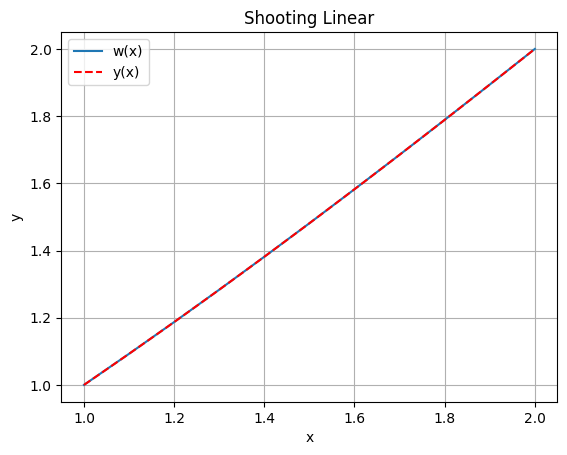

In [7]:
plt.plot(t,y_rk[0], label = "w(x)")
plt.title("Shooting Linear")
plt.plot(np.linspace(1,2),real_f(np.linspace(1,2)), label = "y(x)", linestyle = '--', color = 'red')
plt.grid()
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()